<a href="https://colab.research.google.com/github/Hui0223/pytorch-deep-learning/blob/main/01_pytorch_workflow_video_model_1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Putting it all together

In [8]:
import torch
from torch import nn
import matplotlib.pyplot as plt

torch.__version__

'2.11.0+cpu'

In [9]:
device = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Using device:{device}")

Using device:cpu


6.1 Data

hard-code : weight/bias

make a range of numbers between 0 and 1 -> x values.

y = weight * x + bias

In [10]:
weight = 0.6
bias = 0.4

start = 0
end = 1
step = 0.01

X = torch.arange(start,end,step).unsqueeze(dim=1)
y = weight * X + bias
X[:10], y[:10]

(tensor([[0.0000],
         [0.0100],
         [0.0200],
         [0.0300],
         [0.0400],
         [0.0500],
         [0.0600],
         [0.0700],
         [0.0800],
         [0.0900]]),
 tensor([[0.4000],
         [0.4060],
         [0.4120],
         [0.4180],
         [0.4240],
         [0.4300],
         [0.4360],
         [0.4420],
         [0.4480],
         [0.4540]]))

In [11]:
# Split data
train_split = int(0.8 * len(X))
X_train, y_train = X[:train_split], y[:train_split]
X_test, y_test = X[train_split:], y[train_split:]

len(X_train), len(y_train), len(X_test), len(y_test)

(80, 80, 20, 20)

In [15]:
from prompt_toolkit.shortcuts.progress_bar import Label
# 可视化绘图
def plot_predictions(train_data=X_train,train_labels=y_train,test_data=X_test,test_labels=y_test,predictions=None):
  plt.figure(figsize=(10,7))

  # Plot training data in blue, test data in green
  plt.scatter(train_data,train_labels,c="b",s=4,label="Training data")
  plt.scatter(test_data,test_labels,c="g",s=4,label="Testing data")

  if predictions is not None:
    plt.scatter(test_data,predictions,c="r",s=4,label="Predictions")

  plt.legend(prop={"size":14});

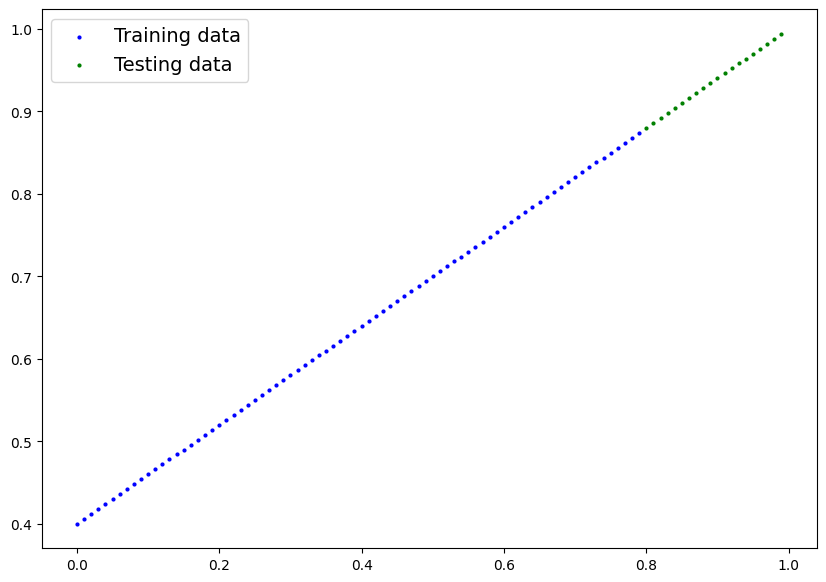

In [16]:
plot_predictions(X_train,y_train,X_test,y_test)

**6.2 Building a PyTorch linear model**

before, we hard code weight and bias using nn.Parameter().

This time, we'll use nn.Linear(in_features, out_features) to do it for us.

Where in_features is the number of dimensions your input data has, and out_features is the number of dimensions you'd like it to be output to.

In our case, both of these are 1 since our data has 1 input feature (X) per label(y).

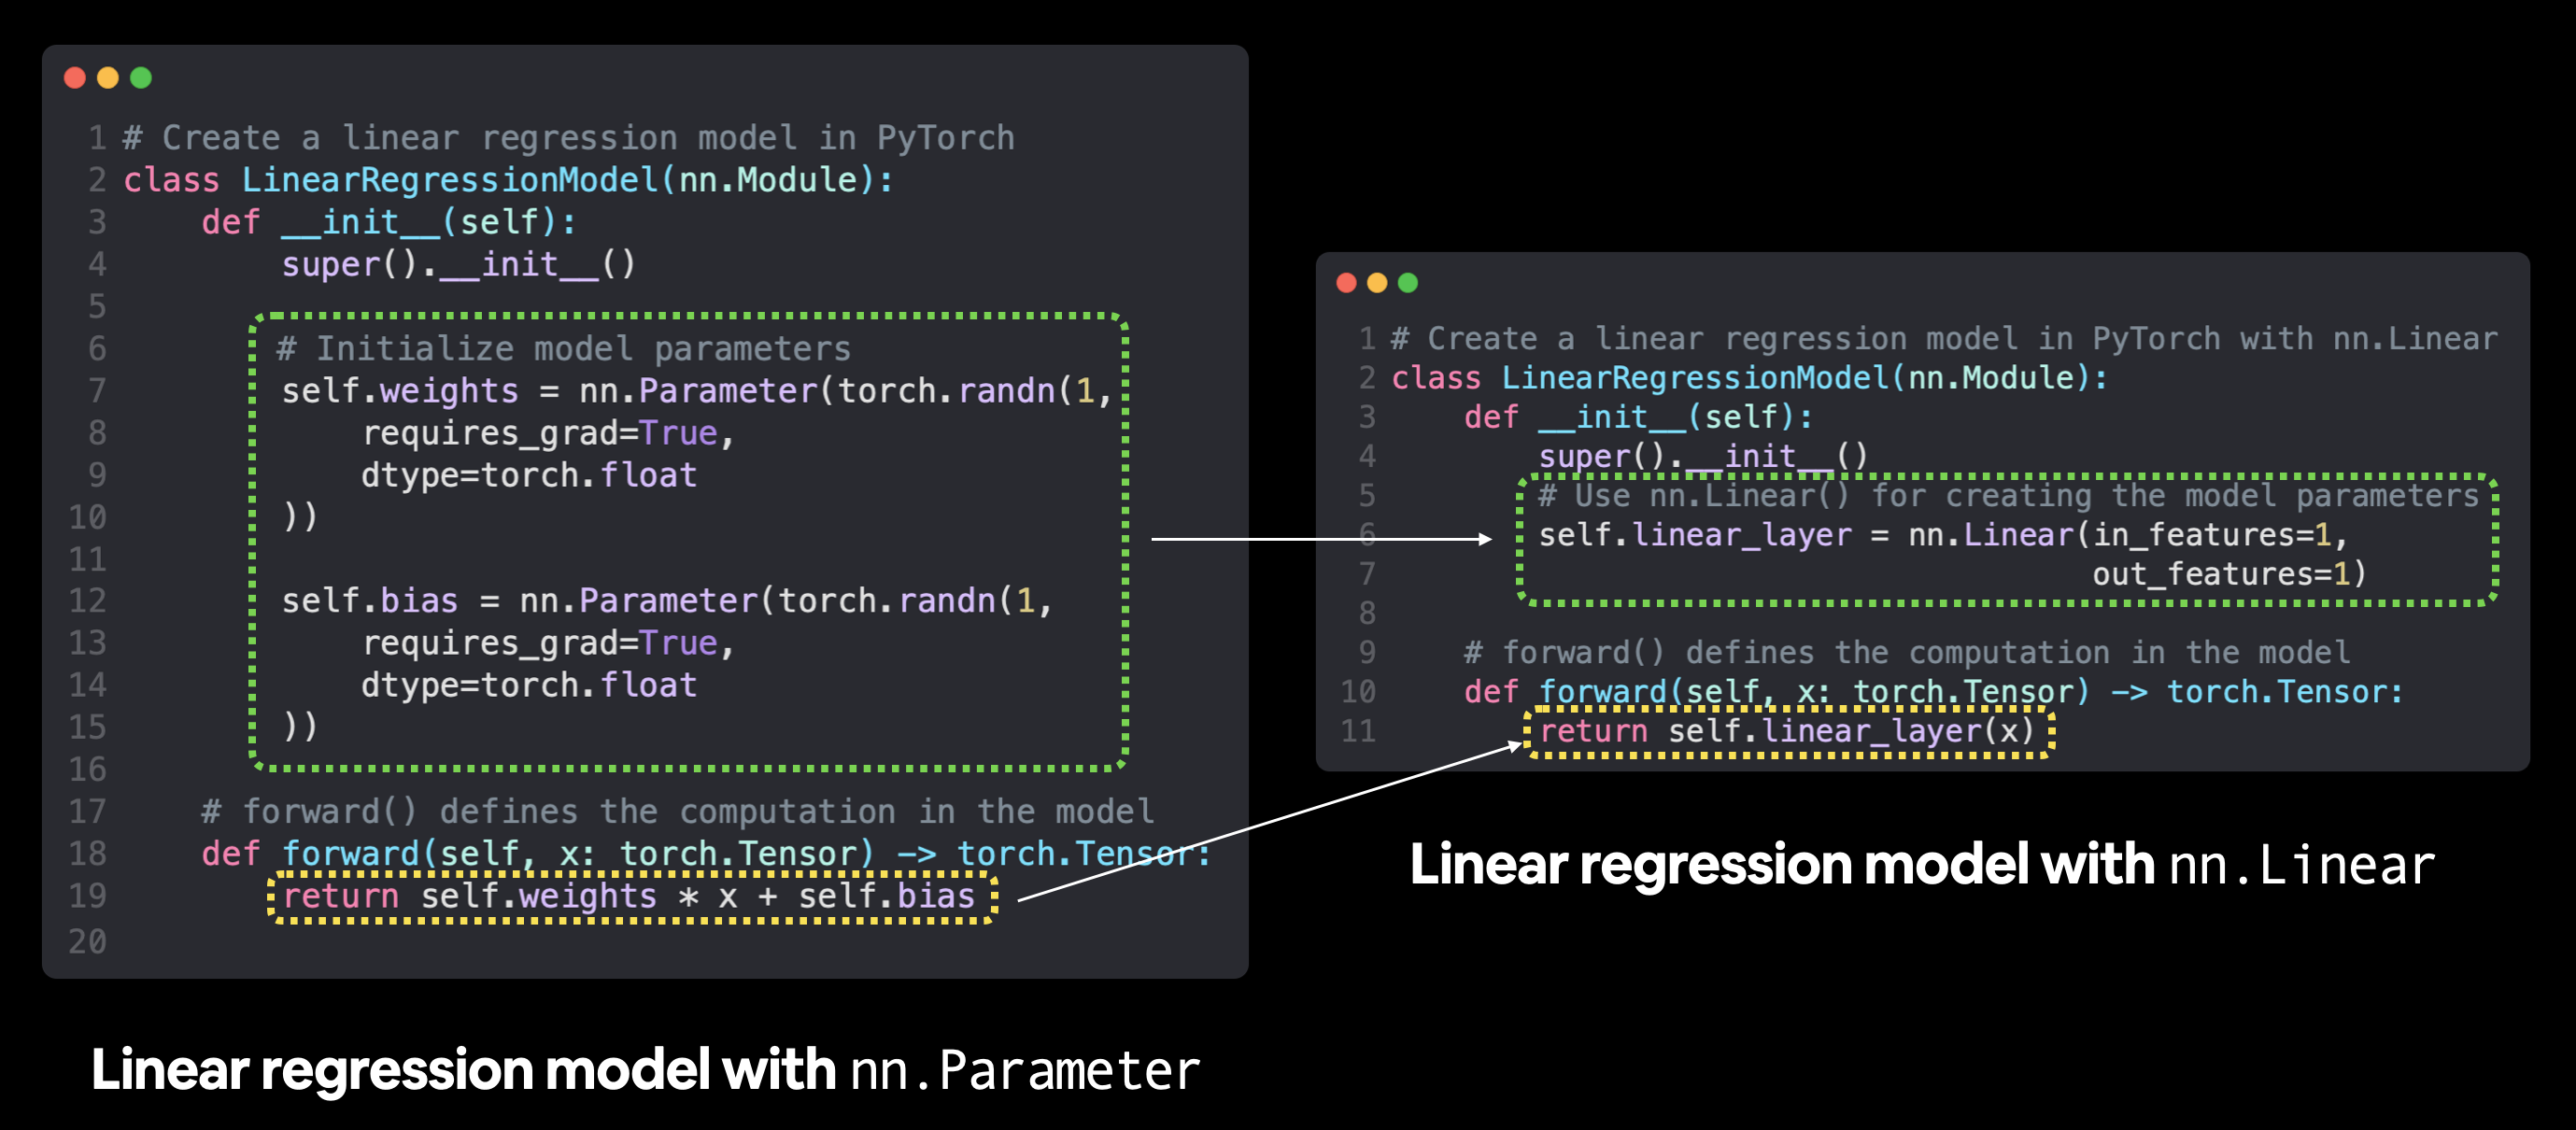

In [17]:
# Subclass nn.Module to make our model

class LinearRegressionModelV2(nn.Module):
  def __init__(self):
    super().__init__()
    # Use nn.Linear() for creating the model parameters
    self.linear_layer = nn.Linear(in_features=1,out_features=1)

  # Define the forward computation (input data x flows through nn.Linear())
  def forward(self,x:torch.Tensor) -> torch.Tensor:
    return self.linear_layer(x)

# Set the manual seed when creating the model
torch.manual_seed(42)
model_1 = LinearRegressionModelV2()
model_1, model_1.state_dict()

(LinearRegressionModelV2(
   (linear_layer): Linear(in_features=1, out_features=1, bias=True)
 ),
 OrderedDict([('linear_layer.weight', tensor([[0.7645]])),
              ('linear_layer.bias', tensor([0.8300]))]))

movde data from CPU (default) to GPU. all data should exist in the same device.

In [18]:
# Check model device
next(model_1.parameters()).device

device(type='cpu')

In [20]:
# Set model to GPU if it's availble , otherwise it'll default to CPU
model_1.to(device)
next(model_1.parameters()).device

device(type='cpu')

**6.3 Training**

build a training and testing loop

loss function & an optimizer

nn.L1Loss()

torch.optim.SGD()


In [21]:
# Create loss function
loss_fn = nn.L1Loss()

# Create optimizer
optimizer = torch.optim.SGD(params=model_1.parameters(),
              lr=0.01)

In [27]:
torch.manual_seed(42)

# Set the number of epochs
epochs = 1000

# Put data on the availble device, without this, error will happen(all data/model should on the same device)
X_train = X_train.to(device)
y_train = y_train.to(device)
X_test = X_test.to(device)
y_test = y_test.to(device)

for epoch in range(epochs):
  # Training
  model_1.train()

  # 1. Forward pass
  y_pred = model_1(X_train)

  # 2. Calculate loss
  loss = loss_fn(y_pred,y_train)

  # 3. Zero grad optimizer
  optimizer.zero_grad()

  # 4. Loss backward
  loss.backward()

  # 5. Step the optimizer
  optimizer.step()

  # Testing
  model_1.eval() # put the model in evaluation mode for testing(inference)
  # 1. Forward pass
  with torch.inference_mode():
    test_pred = model_1(X_test)

    # 2. calculate the loss
    test_loss = loss_fn(test_pred,y_test)

  if epoch % 100 == 0:
    print(f"Epoch:{epoch} | Train loss: {loss} | Test loss: {test_loss}")


Epoch:0 | Train loss: 0.009220534935593605 | Test loss: 0.004995444323867559
Epoch:100 | Train loss: 0.009220534935593605 | Test loss: 0.004995444323867559
Epoch:200 | Train loss: 0.009220534935593605 | Test loss: 0.004995444323867559
Epoch:300 | Train loss: 0.009220534935593605 | Test loss: 0.004995444323867559
Epoch:400 | Train loss: 0.009220534935593605 | Test loss: 0.004995444323867559
Epoch:500 | Train loss: 0.009220534935593605 | Test loss: 0.004995444323867559
Epoch:600 | Train loss: 0.009220534935593605 | Test loss: 0.004995444323867559
Epoch:700 | Train loss: 0.009220534935593605 | Test loss: 0.004995444323867559
Epoch:800 | Train loss: 0.009220534935593605 | Test loss: 0.004995444323867559
Epoch:900 | Train loss: 0.009220534935593605 | Test loss: 0.004995444323867559


In [28]:
# Finding our model's learned parameters
from pprint import pprint
print(f"The model learned the following values for weights and bias:")
pprint(model_1.state_dict())
print("\nAnd the original values for weights and bias are:")
print(f"weights: {weight}, bias: {bias}")

The model learned the following values for weights and bias:
OrderedDict([('linear_layer.weight', tensor([[0.5986]])),
             ('linear_layer.bias', tensor([0.4098]))])

And the original values for weights and bias are:
weights: 0.6, bias: 0.4


**6.4 Making predictions**

In [29]:
# Turn model into evaluation mode
model_1.eval()

# Make predictions on the test data
with torch.inference_mode():
  y_preds = model_1(X_test)

y_preds

tensor([[0.8887],
        [0.8947],
        [0.9006],
        [0.9066],
        [0.9126],
        [0.9186],
        [0.9246],
        [0.9306],
        [0.9366],
        [0.9425],
        [0.9485],
        [0.9545],
        [0.9605],
        [0.9665],
        [0.9725],
        [0.9785],
        [0.9845],
        [0.9904],
        [0.9964],
        [1.0024]])

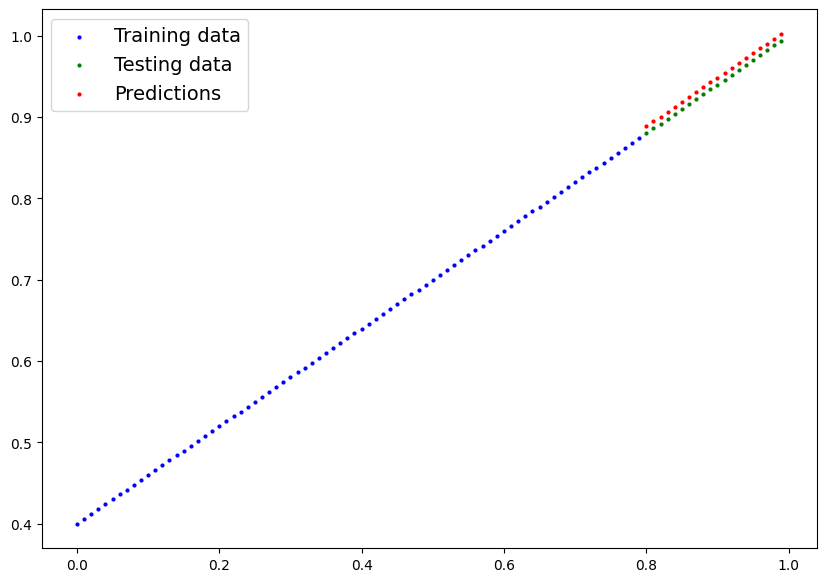

In [30]:
plot_predictions(predictions=y_preds)

**6.5 Saving and loading a model**

In [33]:
from pathlib import Path

MODEL_PATH = Path("models")
MODEL_PATH.mkdir(parents=True, exist_ok=True)

MODEL_NAME = "01_pytoch_workflow_model_1.pth"
MODEL_SAVE_PATH = MODEL_PATH / MODEL_NAME

print(f"Saving model to:{MODEL_SAVE_PATH}")
torch.save(obj=model_1.state_dict(),
     f=MODEL_SAVE_PATH)

Saving model to:models/01_pytoch_workflow_model_1.pth
